In [1]:
import os, time, json, numpy as np, torch
from PIL import Image
from diffusers import StableDiffusionPipeline

/home/hice1/yoh88/Out-of-distribution-Mukhopadhyay-gatech/kernel/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["HF_HOME"] = "/storage/ice1/7/6/yoh88/hf_cache"

device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Manojb/stable-diffusion-2-base"

print(f"Loading {model_id} onto {device}...")

t0 = time.perf_counter()

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    cache_dir="/storage/ice1/7/6/yoh88/hf_cache",
    torch_dtype=torch.float16 if device =="cuda" else torch.float32
).to(device)

if device == "cuda": torch.cuda.synchronize()

cold_start_time = time.perf_counter() - t0
print(f"Pipeline loaded successfully!")
print(f"Cold Start Load Time: {cold_start_time:.2f} seconds")
print(f"Peak VRAM Allocated: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Loading Manojb/stable-diffusion-2-base onto cuda...


Loading pipeline components...: 100%|██████████████████████████████████████████████████████████| 6/6 [00:35<00:00,  5.97s/it]


Pipeline loaded successfully!
Cold Start Load Time: 36.47 seconds
Peak VRAM Allocated: 2.60 GB


In [3]:
def profiled_generate_sona_outlier(
    pipe,
    input_image_path,
    id_class_prompt,
    ood_target_prompt,
    stop_timestep=20,
    guidance_scale=15.0,
    threshold_percentile=0.10,
    adaptive_mask=False,
    device="cuda"
):
    """
    Executes baseline SONA with fine-grained GPU event timing for performance analysis.
    """
     # Create CUDA Events for precise timing
    start_event = torch.cuda.Event(enable_timing=True)
    vae_enc_event = torch.cuda.Event(enable_timing=True)
    text_enc_event = torch.cuda.Event(enable_timing=True)
    unet_loop_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    # -------------------------------------------------------------
    # PHASE 1: Image Preprocessing & VAE Encode
    # -------------------------------------------------------------
    raw_img = Image.open(input_image_path).convert("RGB").resize((512, 512))
    img_tensor = np.array(raw_img).astype(np.float32) / 127.5 - 1.0
    img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device, dtype=pipe.unet.dtype)

    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)
    with torch.no_grad():
        init_latents = pipe.vae.encode(img_tensor).latent_dist.sample(generator=generator)
        init_latents = init_latents * pipe.vae.config.scaling_factor
    vae_enc_event.record()
    # -------------------------------------------------------------
    # PHASE 2: Tokenize & Text Encoder Embeddings
    # -------------------------------------------------------------
    text_prompts = [id_class_prompt, ood_target_prompt, ""]
    text_inputs = pipe.tokenizer(
        text_prompts, 
        padding="max_length", 
        max_length=pipe.tokenizer.model_max_length, 
        return_tensors="pt"
    )
    
    with torch.no_grad():
        embeddings = pipe.text_encoder(text_inputs.input_ids.to(device))[0]
    
    c_id = embeddings[0].unsqueeze(0)
    c_ood = embeddings[1].unsqueeze(0)
    c_uncond = embeddings[2].unsqueeze(0)
    text_enc_event.record()
    # -------------------------------------------------------------
    # PHASE 3: Forward Noise Injection & Reverse Denoising Loop
    # -------------------------------------------------------------
    pipe.scheduler.set_timesteps(50)
    timesteps = pipe.scheduler.timesteps
    start_step_idx = 50 - stop_timestep
    t_start = timesteps[start_step_idx]
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)
    noise = torch.randn(init_latents.shape, generator=generator, device=device, dtype=init_latents.dtype)
    z_t = pipe.scheduler.add_noise(init_latents, noise, t_start)
    # Accumulators for inner loop breakdown
    total_unet_time_ms = 0.0
    total_math_time_ms = 0.0
    u_start = torch.cuda.Event(enable_timing=True)
    u_mid = torch.cuda.Event(enable_timing=True)
    u_end = torch.cuda.Event(enable_timing=True)
    with torch.no_grad():
        for i in range(start_step_idx, len(timesteps)):
            t = timesteps[i]
            
            u_start.record()
            # 3 Separate Sequential UNet forward calls
            eps_uncond = pipe.unet(z_t, t, encoder_hidden_states=c_uncond).sample
            eps_id_cond = pipe.unet(z_t, t, encoder_hidden_states=c_id).sample
            eps_ood_cond = pipe.unet(z_t, t, encoder_hidden_states=c_ood).sample
            u_mid.record()
            # Vector math, dynamic quantile mask calculation, guidance assembly
            psi_id = eps_id_cond - eps_uncond
            psi_ood = eps_ood_cond - eps_uncond
            
            mag_id = torch.abs(psi_id).mean(dim=1, keepdim=True)
            mag_ood = torch.abs(psi_ood).mean(dim=1, keepdim=True)
            
            if adaptive_mask:
                max_val = mag_id.max()
                active_pixels = (mag_id >= 0.15 * max_val).float()
                coverage = active_pixels.mean().item()
                t_percentile = np.clip(coverage * 1.2, 0.08, 0.40)
            else:
                t_percentile = threshold_percentile
            eta_s = torch.quantile(mag_id.float().flatten(), 1.0 - t_percentile).to(mag_id.dtype)
            m_s_id = (mag_id >= eta_s).to(psi_id.dtype)
            
            eta_n = torch.quantile(mag_id.float().flatten(), threshold_percentile).to(mag_id.dtype)
            m_n_id = (mag_id < eta_n).to(psi_id.dtype)
            
            if adaptive_mask:
                max_ood = mag_ood.max()
                active_ood = (mag_ood >= 0.15 * max_ood).float()
                coverage_ood = active_ood.mean().item()
                t_percentile_ood = np.clip(coverage_ood * 1.2, 0.08, 0.40)
            else:
                t_percentile_ood = threshold_percentile
            eta_ood = torch.quantile(mag_ood.float().flatten(), 1.0 - t_percentile_ood).to(mag_ood.dtype)
            m_s_ood = (mag_ood >= eta_ood).to(psi_ood.dtype)
            
            delta_id = -m_s_id * psi_id
            delta_ood = m_s_ood * (1.0 - m_n_id) * psi_ood
            delta_n = m_n_id * psi_id
            
            eps_guided = eps_uncond + guidance_scale * (delta_id + delta_ood + delta_n)
            z_t = pipe.scheduler.step(eps_guided, t, z_t).prev_sample
            u_end.record()
            torch.cuda.synchronize()
            total_unet_time_ms += u_start.elapsed_time(u_mid)
            total_math_time_ms += u_mid.elapsed_time(u_end)
    unet_loop_event.record()
    # -------------------------------------------------------------
    # PHASE 4: VAE Decode Latents to Image
    # -------------------------------------------------------------
    with torch.no_grad():
        decoded = pipe.vae.decode(z_t / pipe.vae.config.scaling_factor).sample
        decoded = (decoded / 2 + 0.5).clamp(0, 1)
        decoded = decoded.cpu().permute(0, 2, 3, 1).float().numpy()[0]
        out_img = Image.fromarray((decoded * 255).astype(np.uint8)).resize(raw_img.size)
    end_event.record()
    torch.cuda.synchronize()
    # Compute phase timings in milliseconds
    metrics = {
        "vae_encode_ms": start_event.elapsed_time(vae_enc_event),
        "text_encode_ms": vae_enc_event.elapsed_time(text_enc_event),
        "unet_inferences_ms": total_unet_time_ms,
        "mask_and_scheduler_math_ms": total_math_time_ms,
        "vae_decode_ms": unet_loop_event.elapsed_time(end_event),
        "total_warm_start_ms": start_event.elapsed_time(end_event),
        "steps_count": len(timesteps) - start_step_idx
    }
    return out_img, metrics


In [4]:
# -------------------------------------------------------------
# 1. Define Test Data & Prompts
# -------------------------------------------------------------
test_img_path = "/storage/ice-shared/cs8903onl/kernel-datasets/data/images_largescale/imagenet_1k/train/n01484850/n01484850_22902.JPEG"
id_prompt = "a photo of a great white shark"
ood_prompt = "a photo of a harvester"

# -------------------------------------------------------------
# 2. Run 1 Untimed Warmup Iteration
# -------------------------------------------------------------
print("Running 1 Untimed Warmup Iteration...")
_, _ = profiled_generate_sona_outlier(
    pipe, 
    input_image_path=test_img_path, 
    id_class_prompt=id_prompt, 
    ood_target_prompt=ood_prompt, 
    stop_timestep=23,
    guidance_scale=10.0,
    threshold_percentile=0.2
)
print("Warmup complete\n")

# -------------------------------------------------------------
# 3. Run N Steady-State Benchmark Iterations
# -------------------------------------------------------------
NUM_RUNS = 5
print(f"Step 2: Running {NUM_RUNS} Steady-State Benchmark Iterations...")

metrics_list = []
for run in range(NUM_RUNS):
    img, m = profiled_generate_sona_outlier(
        pipe, 
        input_image_path=test_img_path, 
        id_class_prompt=id_prompt, 
        ood_target_prompt=ood_prompt, 
        stop_timestep=23,
        guidance_scale=10.0,
        threshold_percentile=0.2
    )
    metrics_list.append(m)
    print(f"  Run {run+1}/{NUM_RUNS}: {m['total_warm_start_ms']:.2f} ms ({m['total_warm_start_ms']/1000:.3f} s)")

# -------------------------------------------------------------
# 4. Compute Averages & Display Benchmark Summary Table
# -------------------------------------------------------------
avg_metrics = {k: np.mean([m[k] for m in metrics_list]) for k in metrics_list[0].keys()}

total_ms = avg_metrics['total_warm_start_ms']

print("\n" + "="*70)
print(f"BASELINE SONA PROFILE BREAKDOWN (Averaged over {NUM_RUNS} runs)")
print("="*70)
print(f"1. VAE Encode (Image -> Latent)     : {avg_metrics['vae_encode_ms']:8.2f} ms ({avg_metrics['vae_encode_ms']/total_ms*100:5.1f}%)")
print(f"2. Text Encoder (CLIP Embeddings)   : {avg_metrics['text_encode_ms']:8.2f} ms ({avg_metrics['text_encode_ms']/total_ms*100:5.1f}%)")
print(f"3. UNet Inferences (3x per step)    : {avg_metrics['unet_inferences_ms']:8.2f} ms ({avg_metrics['unet_inferences_ms']/total_ms*100:5.1f}%)")
print(f"4. Mask Math & Scheduler Steps     : {avg_metrics['mask_and_scheduler_math_ms']:8.2f} ms ({avg_metrics['mask_and_scheduler_math_ms']/total_ms*100:5.1f}%)")
print(f"5. VAE Decode (Latent -> Image)     : {avg_metrics['vae_decode_ms']:8.2f} ms ({avg_metrics['vae_decode_ms']/total_ms*100:5.1f}%)")
print("-" * 70)
print(f"⏱TOTAL WARM-START LATENCY PER IMAGE : {total_ms:8.2f} ms ({total_ms/1000:.3f} s)")
print("="*70)


Running 1 Untimed Warmup Iteration...
Warmup complete

Step 2: Running 5 Steady-State Benchmark Iterations...
  Run 1/5: 1694.65 ms (1.695 s)
  Run 2/5: 1694.00 ms (1.694 s)
  Run 3/5: 1692.12 ms (1.692 s)
  Run 4/5: 1689.15 ms (1.689 s)
  Run 5/5: 1687.05 ms (1.687 s)

BASELINE SONA PROFILE BREAKDOWN (Averaged over 5 runs)
1. VAE Encode (Image -> Latent)     :    24.78 ms (  1.5%)
2. Text Encoder (CLIP Embeddings)   :     6.29 ms (  0.4%)
3. UNet Inferences (3x per step)    :  1600.08 ms ( 94.6%)
4. Mask Math & Scheduler Steps     :    23.93 ms (  1.4%)
5. VAE Decode (Latent -> Image)     :    34.80 ms (  2.1%)
----------------------------------------------------------------------
⏱TOTAL WARM-START LATENCY PER IMAGE :  1691.39 ms (1.691 s)


In [ ]:
def profiled_generate_sona_outlier_optimized1(
    pipe,
    input_image_path,
    id_class_prompt,
    ood_target_prompt,
    stop_timestep=20,
    guidance_scale=15.0,
    threshold_percentile=0.10,
    adaptive_mask=False,
    device="cuda"
):
    """
    Executes baseline SONA with fine-grained GPU event timing for performance analysis.
    """
     # Create CUDA Events for precise timing
    start_event = torch.cuda.Event(enable_timing=True)
    vae_enc_event = torch.cuda.Event(enable_timing=True)
    text_enc_event = torch.cuda.Event(enable_timing=True)
    unet_loop_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    # -------------------------------------------------------------
    # PHASE 1: Image Preprocessing & VAE Encode
    # -------------------------------------------------------------
    raw_img = Image.open(input_image_path).convert("RGB").resize((512, 512))
    img_tensor = np.array(raw_img).astype(np.float32) / 127.5 - 1.0
    img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device, dtype=pipe.unet.dtype)
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)
    with torch.no_grad():
        init_latents = pipe.vae.encode(img_tensor).latent_dist.sample(generator=generator)
        init_latents = init_latents * pipe.vae.config.scaling_factor
    vae_enc_event.record()
    # -------------------------------------------------------------
    # PHASE 2: Tokenize & Text Encoder Embeddings
    # -------------------------------------------------------------
    text_prompts = [id_class_prompt, ood_target_prompt, ""]
    text_inputs = pipe.tokenizer(
        text_prompts, 
        padding="max_length", 
        max_length=pipe.tokenizer.model_max_length, 
        return_tensors="pt"
    )
    
    with torch.no_grad():
        embeddings = pipe.text_encoder(text_inputs.input_ids.to(device))[0]
    
    c_id = embeddings[0].unsqueeze(0)
    c_ood = embeddings[1].unsqueeze(0)
    c_uncond = embeddings[2].unsqueeze(0)
    text_enc_event.record()
    # -------------------------------------------------------------
    # PHASE 3: Forward Noise Injection & Reverse Denoising Loop
    # -------------------------------------------------------------
    pipe.scheduler.set_timesteps(50)
    timesteps = pipe.scheduler.timesteps
    start_step_idx = 50 - stop_timestep
    t_start = timesteps[start_step_idx]
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)
    noise = torch.randn(init_latents.shape, generator=generator, device=device, dtype=init_latents.dtype)
    z_t = pipe.scheduler.add_noise(init_latents, noise, t_start)
    # z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
    c_batched = torch.cat([c_uncond, c_id, c_ood], dim=0)
    # Accumulators for inner loop breakdown
    total_unet_time_ms = 0.0
    total_math_time_ms = 0.0
    u_start = torch.cuda.Event(enable_timing=True)
    u_mid = torch.cuda.Event(enable_timing=True)
    u_end = torch.cuda.Event(enable_timing=True)
    with torch.no_grad():
        for i in range(start_step_idx, len(timesteps)):
            t = timesteps[i]
            
            u_start.record()
            # 3 Separate Sequential UNet forward calls
            # eps_uncond = pipe.unet(z_t, t, encoder_hidden_states=c_uncond).sample
            # eps_id_cond = pipe.unet(z_t, t, encoder_hidden_states=c_id).sample
            # eps_ood_cond = pipe.unet(z_t, t, encoder_hidden_states=c_ood).sample
            z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
            eps_batched = pipe.unet(z_t_batched, t, encoder_hidden_states=c_batched).sample
            eps_uncond, eps_id_cond, eps_ood_cond = eps_batched.chunk(3, dim=0)
            u_mid.record()
            # Vector math, dynamic quantile mask calculation, guidance assembly
            psi_id = eps_id_cond - eps_uncond
            psi_ood = eps_ood_cond - eps_uncond
            
            mag_id = torch.abs(psi_id).mean(dim=1, keepdim=True)
            mag_ood = torch.abs(psi_ood).mean(dim=1, keepdim=True)
            
            if adaptive_mask:
                max_val = mag_id.max()
                active_pixels = (mag_id >= 0.15 * max_val).float()
                coverage = active_pixels.mean().item()
                t_percentile = np.clip(coverage * 1.2, 0.08, 0.40)
            else:
                t_percentile = threshold_percentile
            eta_s = torch.quantile(mag_id.float().flatten(), 1.0 - t_percentile).to(mag_id.dtype)
            m_s_id = (mag_id >= eta_s).to(psi_id.dtype)
            
            eta_n = torch.quantile(mag_id.float().flatten(), threshold_percentile).to(mag_id.dtype)
            m_n_id = (mag_id < eta_n).to(psi_id.dtype)
            
            if adaptive_mask:
                max_ood = mag_ood.max()
                active_ood = (mag_ood >= 0.15 * max_ood).float()
                coverage_ood = active_ood.mean().item()
                t_percentile_ood = np.clip(coverage_ood * 1.2, 0.08, 0.40)
            else:
                t_percentile_ood = threshold_percentile
            eta_ood = torch.quantile(mag_ood.float().flatten(), 1.0 - t_percentile_ood).to(mag_ood.dtype)
            m_s_ood = (mag_ood >= eta_ood).to(psi_ood.dtype)
            
            delta_id = -m_s_id * psi_id
            delta_ood = m_s_ood * (1.0 - m_n_id) * psi_ood
            delta_n = m_n_id * psi_id
            
            eps_guided = eps_uncond + guidance_scale * (delta_id + delta_ood + delta_n)
            z_t = pipe.scheduler.step(eps_guided, t, z_t).prev_sample
            u_end.record()
            torch.cuda.synchronize()
            total_unet_time_ms += u_start.elapsed_time(u_mid)
            total_math_time_ms += u_mid.elapsed_time(u_end)
    unet_loop_event.record()
    # -------------------------------------------------------------
    # PHASE 4: VAE Decode Latents to Image
    # -------------------------------------------------------------
    with torch.no_grad():
        decoded = pipe.vae.decode(z_t / pipe.vae.config.scaling_factor).sample
        decoded = (decoded / 2 + 0.5).clamp(0, 1)
        decoded = decoded.cpu().permute(0, 2, 3, 1).float().numpy()[0]
        out_img = Image.fromarray((decoded * 255).astype(np.uint8)).resize(raw_img.size)
    end_event.record()
    torch.cuda.synchronize()
    # Compute phase timings in milliseconds
    metrics = {
        "vae_encode_ms": start_event.elapsed_time(vae_enc_event),
        "text_encode_ms": vae_enc_event.elapsed_time(text_enc_event),
        "unet_inferences_ms": total_unet_time_ms,
        "mask_and_scheduler_math_ms": total_math_time_ms,
        "vae_decode_ms": unet_loop_event.elapsed_time(end_event),
        "total_warm_start_ms": start_event.elapsed_time(end_event),
        "steps_count": len(timesteps) - start_step_idx
    }
    return out_img, metrics


In [6]:
# -------------------------------------------------------------
# 1. Define Test Data & Prompts
# -------------------------------------------------------------
test_img_path = "/storage/ice-shared/cs8903onl/kernel-datasets/data/images_largescale/imagenet_1k/train/n01484850/n01484850_22902.JPEG"
id_prompt = "a photo of a great white shark"
ood_prompt = "a photo of a harvester"

# -------------------------------------------------------------
# 2. Run 1 Untimed Warmup Iteration
# -------------------------------------------------------------
print("Running 1 Untimed Warmup Iteration...")
_, _ = profiled_generate_sona_outlier_optimized1(
    pipe, 
    input_image_path=test_img_path, 
    id_class_prompt=id_prompt, 
    ood_target_prompt=ood_prompt, 
    stop_timestep=23,
    guidance_scale=10.0,
    threshold_percentile=0.2
)
print("Warmup complete\n")

# -------------------------------------------------------------
# 3. Run N Steady-State Benchmark Iterations
# -------------------------------------------------------------
NUM_RUNS = 5
print(f"Step 2: Running {NUM_RUNS} Steady-State Benchmark Iterations...")

batched_metrics_list = []
for run in range(NUM_RUNS):
    img_opt1, m_opt1 = profiled_generate_sona_outlier_optimized1(
        pipe, 
        input_image_path=test_img_path, 
        id_class_prompt=id_prompt, 
        ood_target_prompt=ood_prompt, 
        stop_timestep=23,
        guidance_scale=10.0,
        threshold_percentile=0.2
    )
    batched_metrics_list.append(m_opt1)
    print(f"  Run {run+1}/{NUM_RUNS}: {m_opt1['total_warm_start_ms']:.2f} ms ({m_opt1['total_warm_start_ms']/1000:.3f} s)")

# -------------------------------------------------------------
# 4. Compute Averages & Display Benchmark Summary Table
# -------------------------------------------------------------
avg_opt1 = {k: np.mean([m[k] for m in batched_metrics_list]) for k in batched_metrics_list[0].keys()}

total_ms = avg_opt1['total_warm_start_ms']

print("\n" + "="*70)
print(f"BASELINE SONA PROFILE BREAKDOWN (Averaged over {NUM_RUNS} runs)")
print("="*70)
print(f"1. VAE Encode (Image -> Latent)     : {avg_opt1['vae_encode_ms']:8.2f} ms ({avg_opt1['vae_encode_ms']/total_ms*100:5.1f}%)")
print(f"2. Text Encoder (CLIP Embeddings)   : {avg_opt1['text_encode_ms']:8.2f} ms ({avg_opt1['text_encode_ms']/total_ms*100:5.1f}%)")
print(f"3. UNet Inferences (3x per step)    : {avg_opt1['unet_inferences_ms']:8.2f} ms ({avg_opt1['unet_inferences_ms']/total_ms*100:5.1f}%)")
print(f"4. Mask Math & Scheduler Steps     : {avg_opt1['mask_and_scheduler_math_ms']:8.2f} ms ({avg_opt1['mask_and_scheduler_math_ms']/total_ms*100:5.1f}%)")
print(f"5. VAE Decode (Latent -> Image)     : {avg_opt1['vae_decode_ms']:8.2f} ms ({avg_opt1['vae_decode_ms']/total_ms*100:5.1f}%)")
print("-" * 70)
print(f"⏱TOTAL WARM-START LATENCY PER IMAGE : {total_ms:8.2f} ms ({total_ms/1000:.3f} s)")
print("="*70)


Running 1 Untimed Warmup Iteration...
Warmup complete

Step 2: Running 5 Steady-State Benchmark Iterations...
  Run 1/5: 685.48 ms (0.685 s)
  Run 2/5: 685.82 ms (0.686 s)
  Run 3/5: 685.93 ms (0.686 s)
  Run 4/5: 685.62 ms (0.686 s)
  Run 5/5: 685.93 ms (0.686 s)

BASELINE SONA PROFILE BREAKDOWN (Averaged over 5 runs)
1. VAE Encode (Image -> Latent)     :    24.85 ms (  3.6%)
2. Text Encoder (CLIP Embeddings)   :     6.17 ms (  0.9%)
3. UNet Inferences (3x per step)    :   611.17 ms ( 89.1%)
4. Mask Math & Scheduler Steps     :     6.61 ms (  1.0%)
5. VAE Decode (Latent -> Image)     :    35.71 ms (  5.2%)
----------------------------------------------------------------------
⏱TOTAL WARM-START LATENCY PER IMAGE :   685.75 ms (0.686 s)


In [7]:
# Compare against Baseline (avg_metrics from Cell 3)
baseline_total = avg_metrics['total_warm_start_ms']
opt1_total = avg_opt1['total_warm_start_ms']
speedup = baseline_total / opt1_total
time_saved_ms = baseline_total - opt1_total
print("\n" + "="*75)
print(f"COMPARISON: BASELINE vs OPTIMIZATION 1 (Batched UNet Pass)")
print("="*75)
print(f"Metric                        │ Baseline        │ Opt 1 (Batched) │ Reduction")
print("-" * 75)
print(f"UNet Inferences Latency      │ {avg_metrics['unet_inferences_ms']:8.2f} ms   │ {avg_opt1['unet_inferences_ms']:8.2f} ms    │ {(1 - avg_opt1['unet_inferences_ms']/avg_metrics['unet_inferences_ms'])*100:5.1f}% faster")
print(f"Total Warm-Start Latency     │ {baseline_total:8.2f} ms   │ {opt1_total:8.2f} ms    │ {(1 - opt1_total/baseline_total)*100:5.1f}% faster")
print("-" * 75)
print(f"⚡ OVERALL SPEEDUP FACTOR     │ 1.00x           │ {speedup:5.2f}x          │ Time Saved: {time_saved_ms:.2f} ms/img")
print("="*75)


COMPARISON: BASELINE vs OPTIMIZATION 1 (Batched UNet Pass)
Metric                        │ Baseline        │ Opt 1 (Batched) │ Reduction
---------------------------------------------------------------------------
UNet Inferences Latency      │  1600.08 ms   │   611.17 ms    │  61.8% faster
Total Warm-Start Latency     │  1691.39 ms   │   685.75 ms    │  59.5% faster
---------------------------------------------------------------------------
⚡ OVERALL SPEEDUP FACTOR     │ 1.00x           │  2.47x          │ Time Saved: 1005.64 ms/img


In [8]:
# Quality Check

baseline_arr = np.array(img).astype(np.float32)
opt1_arr = np.array(img_opt1).astype(np.float32)

abs_diff = np.abs(baseline_arr - opt1_arr)
max_pixel_diff = np.max(abs_diff)
mean_pixel_diff = np.mean(abs_diff)
mse = np.mean((baseline_arr - opt1_arr) ** 2)

if mse == 0:
    psnr = float('inf')
else:
    psnr = 20 * np.log10(255.0 / np.sqrt(mse))

print("="*65)
print("QUANTITATIVE IMAGE EQUIVALENCE VERIFICATION")
print("="*65)
print(f"Max Pixel Difference (0-255 scale)  : {max_pixel_diff:.2f}")
print(f"Mean Pixel Difference (0-255 scale) : {mean_pixel_diff:.4f}")
print(f"Mean Squared Error (MSE)            : {mse:.6f}")
print(f"PSNR (Signal-to-Noise Ratio)        : {psnr:.2f} dB")
print("-" * 65)

QUANTITATIVE IMAGE EQUIVALENCE VERIFICATION
Max Pixel Difference (0-255 scale)  : 44.00
Mean Pixel Difference (0-255 scale) : 1.1501
Mean Squared Error (MSE)            : 3.970462
PSNR (Signal-to-Noise Ratio)        : 42.14 dB
-----------------------------------------------------------------


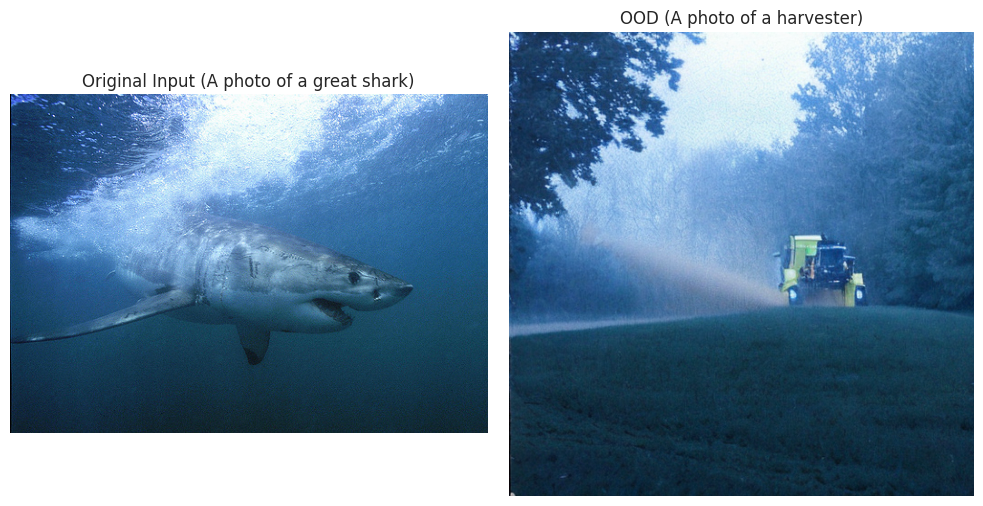

In [88]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# Plot 1: Original Image
orig_img = Image.open(test_img_path).convert("RGB")
axes[0].imshow(orig_img)
axes[0].set_title("Original Input (A photo of a great shark)", fontsize=12)
axes[0].axis("off")
# Plot 2: Baseline SONA Output
axes[1].imshow(img)
axes[1].set_title(f"OOD (A photo of a harvester)", fontsize=12)
axes[1].axis("off")
plt.tight_layout()
plt.savefig('sona_image_comparisons.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
prompt_cache = {}
def get_text_embedding(pipe, prompt_str, device="cuda"):
    """
    Retrieves text embedding from cache if present; otherwise encodes and caches it
    """
    if prompt_str not in prompt_cache:
        text_inputs = pipe.tokenizer(
            [prompt_str],
            padding="max_length",
            max_length=pipe.tokenizer.model_max_length,
            return_tensors="pt"
        )
        with torch.no_grad():
            emb = pipe.text_encoder(text_inputs.input_ids.to(device))[0]
        prompt_cache[prompt_str] = emb
    return prompt_cache[prompt_str]

"""
Optimization 1 (batched UNET Pass) + optimization 2 (text embedding cache)
"""
def profiled_generate_sona_outlier_optimized2(
    pipe,
    input_image_path,
    id_class_prompt,
    ood_target_prompt,
    stop_timestep=20,
    guidance_scale=15.0,
    threshold_percentile=0.10,
    adaptive_mask=False,
    device="cuda"
):
    """
    Executes baseline SONA with fine-grained GPU event timing for performance analysis.
    """
     # Create CUDA Events for precise timing
    start_event = torch.cuda.Event(enable_timing=True)
    vae_enc_event = torch.cuda.Event(enable_timing=True)
    text_enc_event = torch.cuda.Event(enable_timing=True)
    unet_loop_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    # -------------------------------------------------------------
    # PHASE 1: Image Preprocessing & VAE Encode
    # -------------------------------------------------------------
    raw_img = Image.open(input_image_path).convert("RGB").resize((512, 512))
    img_tensor = np.array(raw_img).astype(np.float32) / 127.5 - 1.0
    img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device, dtype=pipe.unet.dtype)
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)
    with torch.no_grad():
        init_latents = pipe.vae.encode(img_tensor).latent_dist.sample(generator=generator)
        init_latents = init_latents * pipe.vae.config.scaling_factor
    vae_enc_event.record()

    # -------------------------------------------------------------
    # PHASE 2: Tokenize & Text Encoder Embeddings
    # -------------------------------------------------------------
    # text_prompts = [id_class_prompt, ood_target_prompt, ""]
    # text_inputs = pipe.tokenizer(
    #     text_prompts, 
    #     padding="max_length", 
    #     max_length=pipe.tokenizer.model_max_length, 
    #     return_tensors="pt"
    # )
    
    # with torch.no_grad():
    #     embeddings = pipe.text_encoder(text_inputs.input_ids.to(device))[0]
    
    c_id = get_text_embedding(pipe, id_class_prompt, device=device)
    c_ood = get_text_embedding(pipe, ood_target_prompt, device=device)
    c_uncond = get_text_embedding(pipe, "", device=device)
    text_enc_event.record()
    # -------------------------------------------------------------
    # PHASE 3: Forward Noise Injection & Reverse Denoising Loop
    # -------------------------------------------------------------
    pipe.scheduler.set_timesteps(50)
    timesteps = pipe.scheduler.timesteps
    start_step_idx = 50 - stop_timestep
    t_start = timesteps[start_step_idx]
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)
    noise = torch.randn(init_latents.shape, generator=generator, device=device, dtype=init_latents.dtype)
    z_t = pipe.scheduler.add_noise(init_latents, noise, t_start)
    # z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
    c_batched = torch.cat([c_uncond, c_id, c_ood], dim=0)
    # Accumulators for inner loop breakdown
    total_unet_time_ms = 0.0
    total_math_time_ms = 0.0
    u_start = torch.cuda.Event(enable_timing=True)
    u_mid = torch.cuda.Event(enable_timing=True)
    u_end = torch.cuda.Event(enable_timing=True)
    with torch.no_grad():
        for i in range(start_step_idx, len(timesteps)):
            t = timesteps[i]
            
            u_start.record()
            # 3 Separate Sequential UNet forward calls
            # eps_uncond = pipe.unet(z_t, t, encoder_hidden_states=c_uncond).sample
            # eps_id_cond = pipe.unet(z_t, t, encoder_hidden_states=c_id).sample
            # eps_ood_cond = pipe.unet(z_t, t, encoder_hidden_states=c_ood).sample
            z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
            eps_batched = pipe.unet(z_t_batched, t, encoder_hidden_states=c_batched).sample
            eps_uncond, eps_id_cond, eps_ood_cond = eps_batched.chunk(3, dim=0)
            u_mid.record()
            # Vector math, dynamic quantile mask calculation, guidance assembly
            psi_id = eps_id_cond - eps_uncond
            psi_ood = eps_ood_cond - eps_uncond
            
            mag_id = torch.abs(psi_id).mean(dim=1, keepdim=True)
            mag_ood = torch.abs(psi_ood).mean(dim=1, keepdim=True)
            
            if adaptive_mask:
                max_val = mag_id.max()
                active_pixels = (mag_id >= 0.15 * max_val).float()
                coverage = active_pixels.mean().item()
                t_percentile = np.clip(coverage * 1.2, 0.08, 0.40)
            else:
                t_percentile = threshold_percentile
            eta_s = torch.quantile(mag_id.float().flatten(), 1.0 - t_percentile).to(mag_id.dtype)
            m_s_id = (mag_id >= eta_s).to(psi_id.dtype)
            
            eta_n = torch.quantile(mag_id.float().flatten(), threshold_percentile).to(mag_id.dtype)
            m_n_id = (mag_id < eta_n).to(psi_id.dtype)
            
            if adaptive_mask:
                max_ood = mag_ood.max()
                active_ood = (mag_ood >= 0.15 * max_ood).float()
                coverage_ood = active_ood.mean().item()
                t_percentile_ood = np.clip(coverage_ood * 1.2, 0.08, 0.40)
            else:
                t_percentile_ood = threshold_percentile
            eta_ood = torch.quantile(mag_ood.float().flatten(), 1.0 - t_percentile_ood).to(mag_ood.dtype)
            m_s_ood = (mag_ood >= eta_ood).to(psi_ood.dtype)
            
            delta_id = -m_s_id * psi_id
            delta_ood = m_s_ood * (1.0 - m_n_id) * psi_ood
            delta_n = m_n_id * psi_id
            
            eps_guided = eps_uncond + guidance_scale * (delta_id + delta_ood + delta_n)
            z_t = pipe.scheduler.step(eps_guided, t, z_t).prev_sample
            u_end.record()
            torch.cuda.synchronize()
            total_unet_time_ms += u_start.elapsed_time(u_mid)
            total_math_time_ms += u_mid.elapsed_time(u_end)
    unet_loop_event.record()
    # -------------------------------------------------------------
    # PHASE 4: VAE Decode Latents to Image
    # -------------------------------------------------------------
    with torch.no_grad():
        decoded = pipe.vae.decode(z_t / pipe.vae.config.scaling_factor).sample
        decoded = (decoded / 2 + 0.5).clamp(0, 1)
        decoded = decoded.cpu().permute(0, 2, 3, 1).float().numpy()[0]
        out_img = Image.fromarray((decoded * 255).astype(np.uint8)).resize(raw_img.size)
    end_event.record()
    torch.cuda.synchronize()
    # Compute phase timings in milliseconds
    metrics = {
        "vae_encode_ms": start_event.elapsed_time(vae_enc_event),
        "text_encode_ms": vae_enc_event.elapsed_time(text_enc_event),
        "unet_inferences_ms": total_unet_time_ms,
        "mask_and_scheduler_math_ms": total_math_time_ms,
        "vae_decode_ms": unet_loop_event.elapsed_time(end_event),
        "total_warm_start_ms": start_event.elapsed_time(end_event),
        "steps_count": len(timesteps) - start_step_idx
    }
    return out_img, metrics


In [11]:
prompt_cache.clear()

# -------------------------------------------------------------
# 1. Define Test Data & Prompts
# -------------------------------------------------------------
test_img_path = "/storage/ice-shared/cs8903onl/kernel-datasets/data/images_largescale/imagenet_1k/train/n01484850/n01484850_22902.JPEG"
id_prompt = "a photo of a great white shark"
ood_prompt = "a photo of a harvester"

# -------------------------------------------------------------
# 2. Run 1 Untimed Warmup Iteration
# -------------------------------------------------------------
print("Running 1 Untimed Warmup Iteration...")
_, _ = profiled_generate_sona_outlier_optimized2(
    pipe, 
    input_image_path=test_img_path, 
    id_class_prompt=id_prompt, 
    ood_target_prompt=ood_prompt, 
    stop_timestep=23,
    guidance_scale=10.0,
    threshold_percentile=0.2
)
print("Warmup complete\n")

# -------------------------------------------------------------
# 3. Run N Steady-State Benchmark Iterations
# -------------------------------------------------------------
NUM_RUNS = 5
print(f"Step 2: Running {NUM_RUNS} Steady-State Benchmark Iterations...")

opt2_metrics_list = []
for run in range(NUM_RUNS):
    img_opt2, m_opt2 = profiled_generate_sona_outlier_optimized2(
        pipe, 
        input_image_path=test_img_path, 
        id_class_prompt=id_prompt, 
        ood_target_prompt=ood_prompt, 
        stop_timestep=23,
        guidance_scale=10.0,
        threshold_percentile=0.2
    )
    opt2_metrics_list.append(m_opt2)
    print(f"  Run {run+1}/{NUM_RUNS}: {m_opt2['total_warm_start_ms']:.2f} ms ({m_opt2['total_warm_start_ms']/1000:.3f} s)")

# -------------------------------------------------------------
# 4. Compute Averages & Display Benchmark Summary Table
# -------------------------------------------------------------
avg_opt2 = {k: np.mean([m[k] for m in opt2_metrics_list]) for k in opt2_metrics_list[0].keys()}

total_ms = avg_opt2['total_warm_start_ms']

print("\n" + "="*70)
print(f"BASELINE SONA PROFILE BREAKDOWN (Averaged over {NUM_RUNS} runs)")
print("="*70)
print(f"1. VAE Encode (Image -> Latent)     : {avg_opt2['vae_encode_ms']:8.2f} ms ({avg_opt2['vae_encode_ms']/total_ms*100:5.1f}%)")
print(f"2. Text Encoder (CLIP Embeddings)   : {avg_opt2['text_encode_ms']:8.2f} ms ({avg_opt2['text_encode_ms']/total_ms*100:5.1f}%)")
print(f"3. UNet Inferences (3x per step)    : {avg_opt2['unet_inferences_ms']:8.2f} ms ({avg_opt2['unet_inferences_ms']/total_ms*100:5.1f}%)")
print(f"4. Mask Math & Scheduler Steps     : {avg_opt2['mask_and_scheduler_math_ms']:8.2f} ms ({avg_opt2['mask_and_scheduler_math_ms']/total_ms*100:5.1f}%)")
print(f"5. VAE Decode (Latent -> Image)     : {avg_opt2['vae_decode_ms']:8.2f} ms ({avg_opt2['vae_decode_ms']/total_ms*100:5.1f}%)")
print("-" * 70)
print(f"⏱TOTAL WARM-START LATENCY PER IMAGE : {total_ms:8.2f} ms ({total_ms/1000:.3f} s)")
print("="*70)


Running 1 Untimed Warmup Iteration...


Warmup complete

Step 2: Running 5 Steady-State Benchmark Iterations...
  Run 1/5: 684.25 ms (0.684 s)
  Run 2/5: 684.05 ms (0.684 s)
  Run 3/5: 684.29 ms (0.684 s)
  Run 4/5: 682.98 ms (0.683 s)
  Run 5/5: 683.51 ms (0.684 s)

BASELINE SONA PROFILE BREAKDOWN (Averaged over 5 runs)
1. VAE Encode (Image -> Latent)     :    25.20 ms (  3.7%)
2. Text Encoder (CLIP Embeddings)   :     0.00 ms (  0.0%)
3. UNet Inferences (3x per step)    :   614.98 ms ( 89.9%)
4. Mask Math & Scheduler Steps     :     6.62 ms (  1.0%)
5. VAE Decode (Latent -> Image)     :    35.88 ms (  5.2%)
----------------------------------------------------------------------
⏱TOTAL WARM-START LATENCY PER IMAGE :   683.82 ms (0.684 s)


In [12]:
# Benchmark comparison table across Baseline, Opt 1, and Opt 2
print("\n" + "="*80)
print(f"3-WAY COMPARISON: BASELINE vs OPT 1 (BATCHED) vs OPT 2 (BATCHED + CACHED)")
print("="*80)
print(f"Phase Latency                │ Baseline    │ Opt 1 (Batched) │ Opt 2 (Cached)")
print("-" * 80)
print(f"Text Encoder Latency         │ {avg_metrics['text_encode_ms']:8.2f} ms │ {avg_opt1['text_encode_ms']:13.2f} ms │ {avg_opt2['text_encode_ms']:12.2f} ms")
print(f"UNet Inferences Latency      │ {avg_metrics['unet_inferences_ms']:8.2f} ms │ {avg_opt1['unet_inferences_ms']:13.2f} ms │ {avg_opt2['unet_inferences_ms']:12.2f} ms")
print(f"Total Warm-Start Latency     │ {baseline_total:8.2f} ms │ {opt1_total:13.2f} ms │ {avg_opt2['total_warm_start_ms']:12.2f} ms")
print("-" * 80)
speedup_opt2 = baseline_total / avg_opt2['total_warm_start_ms']
print(f"OVERALL SPEEDUP FACTOR       │ 1.00x       │ {speedup:13.2f}x │ {speedup_opt2:12.2f}x")
print("="*80)


3-WAY COMPARISON: BASELINE vs OPT 1 (BATCHED) vs OPT 2 (BATCHED + CACHED)
Phase Latency                │ Baseline    │ Opt 1 (Batched) │ Opt 2 (Cached)
--------------------------------------------------------------------------------
Text Encoder Latency         │     6.29 ms │          6.17 ms │         0.00 ms
UNet Inferences Latency      │  1600.08 ms │        611.17 ms │       614.98 ms
Total Warm-Start Latency     │  1691.39 ms │        685.75 ms │       683.82 ms
--------------------------------------------------------------------------------
OVERALL SPEEDUP FACTOR       │ 1.00x       │          2.47x │         2.47x


In [13]:
"""
Optimization 1 (batched UNET Pass) + optimization 2 (text embedding cache) + optimization 3 (inference)
"""
def profiled_generate_sona_outlier_optimized3(
    pipe,
    input_image_path,
    id_class_prompt,
    ood_target_prompt,
    stop_timestep=20,
    guidance_scale=15.0,
    threshold_percentile=0.10,
    adaptive_mask=False,
    device="cuda"
):
    """
    Executes baseline SONA with fine-grained GPU event timing for performance analysis.
    """
     # Create CUDA Events for precise timing
    start_event = torch.cuda.Event(enable_timing=True)
    vae_enc_event = torch.cuda.Event(enable_timing=True)
    text_enc_event = torch.cuda.Event(enable_timing=True)
    unet_loop_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    # -------------------------------------------------------------
    # PHASE 1: Image Preprocessing & VAE Encode
    # -------------------------------------------------------------
    raw_img = Image.open(input_image_path).convert("RGB").resize((512, 512))
    img_tensor = np.array(raw_img).astype(np.float32) / 127.5 - 1.0
    # img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device, dtype=pipe.unet.dtype)
    img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device, dtype=pipe.text_encoder.dtype)
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)

    # opt 3
    with torch.inference_mode():
        init_latents = pipe.vae.encode(img_tensor).latent_dist.sample(generator=generator)
        init_latents = init_latents * pipe.vae.config.scaling_factor
    vae_enc_event.record()

    # -------------------------------------------------------------
    # PHASE 2: Tokenize & Text Encoder Embeddings
    # -------------------------------------------------------------
    # text_prompts = [id_class_prompt, ood_target_prompt, ""]
    # text_inputs = pipe.tokenizer(
    #     text_prompts, 
    #     padding="max_length", 
    #     max_length=pipe.tokenizer.model_max_length, 
    #     return_tensors="pt"
    # )
    
    # with torch.no_grad():
    #     embeddings = pipe.text_encoder(text_inputs.input_ids.to(device))[0]
    
    c_id = get_text_embedding(pipe, id_class_prompt, device=device)
    c_ood = get_text_embedding(pipe, ood_target_prompt, device=device)
    c_uncond = get_text_embedding(pipe, "", device=device)
    text_enc_event.record()
    # -------------------------------------------------------------
    # PHASE 3: Forward Noise Injection & Reverse Denoising Loop
    # -------------------------------------------------------------
    pipe.scheduler.set_timesteps(50)
    timesteps = pipe.scheduler.timesteps
    start_step_idx = 50 - stop_timestep
    t_start = timesteps[start_step_idx]
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(42)
    noise = torch.randn(init_latents.shape, generator=generator, device=device, dtype=init_latents.dtype)
    z_t = pipe.scheduler.add_noise(init_latents, noise, t_start)
    # z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
    c_batched = torch.cat([c_uncond, c_id, c_ood], dim=0)
    # Accumulators for inner loop breakdown
    total_unet_time_ms = 0.0
    total_math_time_ms = 0.0
    u_start = torch.cuda.Event(enable_timing=True)
    u_mid = torch.cuda.Event(enable_timing=True)
    u_end = torch.cuda.Event(enable_timing=True)
    with torch.inference_mode():
        for i in range(start_step_idx, len(timesteps)):
            t = timesteps[i]
            
            u_start.record()
            # 3 Separate Sequential UNet forward calls
            # eps_uncond = pipe.unet(z_t, t, encoder_hidden_states=c_uncond).sample
            # eps_id_cond = pipe.unet(z_t, t, encoder_hidden_states=c_id).sample
            # eps_ood_cond = pipe.unet(z_t, t, encoder_hidden_states=c_ood).sample
            z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
            eps_batched = pipe.unet(z_t_batched, t, encoder_hidden_states=c_batched).sample
            eps_uncond, eps_id_cond, eps_ood_cond = eps_batched.chunk(3, dim=0)
            u_mid.record()
            # Vector math, dynamic quantile mask calculation, guidance assembly
            psi_id = eps_id_cond - eps_uncond
            psi_ood = eps_ood_cond - eps_uncond
            
            mag_id = torch.abs(psi_id).mean(dim=1, keepdim=True)
            mag_ood = torch.abs(psi_ood).mean(dim=1, keepdim=True)
            
            if adaptive_mask:
                max_val = mag_id.max()
                active_pixels = (mag_id >= 0.15 * max_val).float()
                coverage = active_pixels.mean().item()
                t_percentile = np.clip(coverage * 1.2, 0.08, 0.40)
            else:
                t_percentile = threshold_percentile
            eta_s = torch.quantile(mag_id.float().flatten(), 1.0 - t_percentile).to(mag_id.dtype)
            m_s_id = (mag_id >= eta_s).to(psi_id.dtype)
            
            eta_n = torch.quantile(mag_id.float().flatten(), threshold_percentile).to(mag_id.dtype)
            m_n_id = (mag_id < eta_n).to(psi_id.dtype)
            
            if adaptive_mask:
                max_ood = mag_ood.max()
                active_ood = (mag_ood >= 0.15 * max_ood).float()
                coverage_ood = active_ood.mean().item()
                t_percentile_ood = np.clip(coverage_ood * 1.2, 0.08, 0.40)
            else:
                t_percentile_ood = threshold_percentile
            eta_ood = torch.quantile(mag_ood.float().flatten(), 1.0 - t_percentile_ood).to(mag_ood.dtype)
            m_s_ood = (mag_ood >= eta_ood).to(psi_ood.dtype)
            
            delta_id = -m_s_id * psi_id
            delta_ood = m_s_ood * (1.0 - m_n_id) * psi_ood
            delta_n = m_n_id * psi_id
            
            eps_guided = eps_uncond + guidance_scale * (delta_id + delta_ood + delta_n)
            z_t = pipe.scheduler.step(eps_guided, t, z_t).prev_sample
            u_end.record()
            torch.cuda.synchronize()
            total_unet_time_ms += u_start.elapsed_time(u_mid)
            total_math_time_ms += u_mid.elapsed_time(u_end)
    unet_loop_event.record()
    # -------------------------------------------------------------
    # PHASE 4: VAE Decode Latents to Image
    # -------------------------------------------------------------
    with torch.no_grad():
        decoded = pipe.vae.decode(z_t / pipe.vae.config.scaling_factor).sample
        decoded = (decoded / 2 + 0.5).clamp(0, 1)
        decoded = decoded.cpu().permute(0, 2, 3, 1).float().numpy()[0]
        out_img = Image.fromarray((decoded * 255).astype(np.uint8)).resize(raw_img.size)
    end_event.record()
    torch.cuda.synchronize()
    # Compute phase timings in milliseconds
    metrics = {
        "vae_encode_ms": start_event.elapsed_time(vae_enc_event),
        "text_encode_ms": vae_enc_event.elapsed_time(text_enc_event),
        "unet_inferences_ms": total_unet_time_ms,
        "mask_and_scheduler_math_ms": total_math_time_ms,
        "vae_decode_ms": unet_loop_event.elapsed_time(end_event),
        "total_warm_start_ms": start_event.elapsed_time(end_event),
        "steps_count": len(timesteps) - start_step_idx
    }
    return out_img, metrics


In [14]:
prompt_cache.clear()

# -------------------------------------------------------------
# 1. Define Test Data & Prompts
# -------------------------------------------------------------
test_img_path = "/storage/ice-shared/cs8903onl/kernel-datasets/data/images_largescale/imagenet_1k/train/n01484850/n01484850_22902.JPEG"
id_prompt = "a photo of a great white shark"
ood_prompt = "a photo of a harvester"

# -------------------------------------------------------------
# 2. Run 1 Untimed Warmup Iteration
# -------------------------------------------------------------
print("Running 1 Untimed Warmup Iteration...")
_, _ = profiled_generate_sona_outlier_optimized3(
    pipe, 
    input_image_path=test_img_path, 
    id_class_prompt=id_prompt, 
    ood_target_prompt=ood_prompt, 
    stop_timestep=23,
    guidance_scale=10.0,
    threshold_percentile=0.2
)
print("Warmup complete\n")

# -------------------------------------------------------------
# 3. Run N Steady-State Benchmark Iterations
# -------------------------------------------------------------
NUM_RUNS = 5
print(f"Step 2: Running {NUM_RUNS} Steady-State Benchmark Iterations...")

opt3_metrics_list = []
for run in range(NUM_RUNS):
    img_opt3, m_opt3 = profiled_generate_sona_outlier_optimized3(
        pipe, 
        input_image_path=test_img_path, 
        id_class_prompt=id_prompt, 
        ood_target_prompt=ood_prompt, 
        stop_timestep=23,
        guidance_scale=10.0,
        threshold_percentile=0.2
    )
    opt3_metrics_list.append(m_opt3)
    print(f"  Run {run+1}/{NUM_RUNS}: {m_opt3['total_warm_start_ms']:.2f} ms ({m_opt3['total_warm_start_ms']/1000:.3f} s)")

# -------------------------------------------------------------
# 4. Compute Averages & Display Benchmark Summary Table
# -------------------------------------------------------------
avg_opt3 = {k: np.mean([m[k] for m in opt3_metrics_list]) for k in opt3_metrics_list[0].keys()}

total_ms = avg_opt3['total_warm_start_ms']

print("\n" + "="*70)
print(f"BASELINE SONA PROFILE BREAKDOWN (Averaged over {NUM_RUNS} runs)")
print("="*70)
print(f"1. VAE Encode (Image -> Latent)     : {avg_opt3['vae_encode_ms']:8.2f} ms ({avg_opt3['vae_encode_ms']/total_ms*100:5.1f}%)")
print(f"2. Text Encoder (CLIP Embeddings)   : {avg_opt3['text_encode_ms']:8.2f} ms ({avg_opt3['text_encode_ms']/total_ms*100:5.1f}%)")
print(f"3. UNet Inferences (3x per step)    : {avg_opt3['unet_inferences_ms']:8.2f} ms ({avg_opt3['unet_inferences_ms']/total_ms*100:5.1f}%)")
print(f"4. Mask Math & Scheduler Steps     : {avg_opt3['mask_and_scheduler_math_ms']:8.2f} ms ({avg_opt3['mask_and_scheduler_math_ms']/total_ms*100:5.1f}%)")
print(f"5. VAE Decode (Latent -> Image)     : {avg_opt3['vae_decode_ms']:8.2f} ms ({avg_opt3['vae_decode_ms']/total_ms*100:5.1f}%)")
print("-" * 70)
print(f"⏱TOTAL WARM-START LATENCY PER IMAGE : {total_ms:8.2f} ms ({total_ms/1000:.3f} s)")
print("="*70)


Running 1 Untimed Warmup Iteration...


Warmup complete

Step 2: Running 5 Steady-State Benchmark Iterations...
  Run 1/5: 669.39 ms (0.669 s)
  Run 2/5: 669.23 ms (0.669 s)
  Run 3/5: 669.54 ms (0.670 s)
  Run 4/5: 670.27 ms (0.670 s)
  Run 5/5: 669.49 ms (0.669 s)

BASELINE SONA PROFILE BREAKDOWN (Averaged over 5 runs)
1. VAE Encode (Image -> Latent)     :    22.96 ms (  3.4%)
2. Text Encoder (CLIP Embeddings)   :     0.00 ms (  0.0%)
3. UNet Inferences (3x per step)    :   602.75 ms ( 90.0%)
4. Mask Math & Scheduler Steps     :     6.72 ms (  1.0%)
5. VAE Decode (Latent -> Image)     :    35.95 ms (  5.4%)
----------------------------------------------------------------------
⏱TOTAL WARM-START LATENCY PER IMAGE :   669.58 ms (0.670 s)


In [15]:
print("\n" + "="*85)
print(f"4-WAY COMPARISON: BASELINE vs OPT 1 vs OPT 2 vs OPT 3 (INFERENCE MODE)")
print("="*85)
print(f"Phase Latency                │ Baseline    │ Opt 1       │ Opt 2       │ Opt 3 (Inference Mode)")
print("-" * 85)
print(f"UNet Inferences Latency      │ {avg_metrics['unet_inferences_ms']:8.2f} ms │ {avg_opt1['unet_inferences_ms']:9.2f} ms │ {avg_opt2['unet_inferences_ms']:9.2f} ms │ {avg_opt3['unet_inferences_ms']:10.2f} ms")
print(f"Total Warm-Start Latency     │ {baseline_total:8.2f} ms │ {opt1_total:9.2f} ms │ {avg_opt2['total_warm_start_ms']:9.2f} ms │ {avg_opt3['total_warm_start_ms']:10.2f} ms")
print("-" * 85)
speedup_opt3 = baseline_total / avg_opt3['total_warm_start_ms']
print(f"OVERALL SPEEDUP FACTOR       │ 1.00x       │ {speedup:9.2f}x │ {speedup_opt2:9.2f}x │ {speedup_opt3:10.2f}x")
print("="*85)


4-WAY COMPARISON: BASELINE vs OPT 1 vs OPT 2 vs OPT 3 (INFERENCE MODE)
Phase Latency                │ Baseline    │ Opt 1       │ Opt 2       │ Opt 3 (Inference Mode)
-------------------------------------------------------------------------------------
UNet Inferences Latency      │  1600.08 ms │    611.17 ms │    614.98 ms │     602.75 ms
Total Warm-Start Latency     │  1691.39 ms │    685.75 ms │    683.82 ms │     669.58 ms
-------------------------------------------------------------------------------------
OVERALL SPEEDUP FACTOR       │ 1.00x       │      2.47x │      2.47x │       2.53x


In [16]:
## Compilation

import torch
print("Compiling pipe.unet with PyTorch 2.0 TorchInductor (mode='reduce-overhead')...")
t_comp_start = time.perf_counter()

# pipe.unet = torch.compile(pipe.unet, mode="max-autotune", options={"triton.cudagraphs": True})
pipe.unet = torch.compile(pipe.unet, 
                          options={
                            "triton.cudagraphs": True,
                            "max_autotune": True})
if device == "cuda":
    torch.cuda.synchronize()
print(f"UNet marked for compilation. (Setup time: {time.perf_counter() - t_comp_start:.2f} s)")

Compiling pipe.unet with PyTorch 2.0 TorchInductor (mode='reduce-overhead')...
UNet marked for compilation. (Setup time: 1.41 s)


In [17]:
prompt_cache.clear()

# -------------------------------------------------------------
# 1. Define Test Data & Prompts
# -------------------------------------------------------------
test_img_path = "/storage/ice-shared/cs8903onl/kernel-datasets/data/images_largescale/imagenet_1k/train/n01484850/n01484850_22902.JPEG"
id_prompt = "a photo of a great white shark"
ood_prompt = "a photo of a harvester"

# -------------------------------------------------------------
# 2. Run 1 Untimed Warmup Iteration
# -------------------------------------------------------------
print("Running 1 Untimed Warmup Iteration...")

t_warm_start = time.perf_counter()

_, _ = profiled_generate_sona_outlier_optimized3(
    pipe, 
    input_image_path=test_img_path, 
    id_class_prompt=id_prompt, 
    ood_target_prompt=ood_prompt, 
    stop_timestep=23,
    guidance_scale=10.0,
    threshold_percentile=0.2
)
t_warm_end = time.perf_counter()
print(f"JIT Compilation & Warmup Complete! (Compilation Warmup took: {t_warm_end - t_warm_start:.2f} s)\n")

# -------------------------------------------------------------
# 3. Run N Steady-State Benchmark Iterations
# -------------------------------------------------------------
NUM_RUNS = 5
print(f"Step 2: Running {NUM_RUNS} Steady-State Benchmark Iterations...")

opt4_metrics_list = []
for run in range(NUM_RUNS):
    img_opt4, m_opt4 = profiled_generate_sona_outlier_optimized3(
        pipe, 
        input_image_path=test_img_path, 
        id_class_prompt=id_prompt, 
        ood_target_prompt=ood_prompt, 
        stop_timestep=23,
        guidance_scale=10.0,
        threshold_percentile=0.2
    )
    opt4_metrics_list.append(m_opt4)
    print(f"  Run {run+1}/{NUM_RUNS}: {m_opt4['total_warm_start_ms']:.2f} ms ({m_opt4['total_warm_start_ms']/1000:.3f} s)")

# -------------------------------------------------------------
# 4. Compute Averages & Display Benchmark Summary Table
# -------------------------------------------------------------
avg_opt4 = {k: np.mean([m[k] for m in opt4_metrics_list]) for k in opt4_metrics_list[0].keys()}

total_ms = avg_opt4['total_warm_start_ms']

print("\n" + "="*70)
print(f"BASELINE SONA PROFILE BREAKDOWN (Averaged over {NUM_RUNS} runs)")
print("="*70)
print(f"1. VAE Encode (Image -> Latent)     : {avg_opt4['vae_encode_ms']:8.2f} ms ({avg_opt4['vae_encode_ms']/total_ms*100:5.1f}%)")
print(f"2. Text Encoder (CLIP Embeddings)   : {avg_opt4['text_encode_ms']:8.2f} ms ({avg_opt4['text_encode_ms']/total_ms*100:5.1f}%)")
print(f"3. UNet Inferences (3x per step)    : {avg_opt4['unet_inferences_ms']:8.2f} ms ({avg_opt4['unet_inferences_ms']/total_ms*100:5.1f}%)")
print(f"4. Mask Math & Scheduler Steps     : {avg_opt4['mask_and_scheduler_math_ms']:8.2f} ms ({avg_opt4['mask_and_scheduler_math_ms']/total_ms*100:5.1f}%)")
print(f"5. VAE Decode (Latent -> Image)     : {avg_opt4['vae_decode_ms']:8.2f} ms ({avg_opt4['vae_decode_ms']/total_ms*100:5.1f}%)")
print("-" * 70)
print(f"TOTAL WARM-START LATENCY PER IMAGE : {total_ms:8.2f} ms ({total_ms/1000:.3f} s)")
print("="*70)


Running 1 Untimed Warmup Iteration...


/home/hice1/yoh88/Out-of-distribution-Mukhopadhyay-gatech/kernel/lib/python3.10/site-packages/torch/_inductor/select_algorithm.py:4628: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_out_size = out_base.storage().size()
E0801 16:59:19.445000 2856711 torch/_inductor/select_algorithm.py:4888] [0/0] Runtime error during autotuning: 
E0801 16:59:19.445000 2856711 torch/_inductor/select_algorithm.py:4888] [0/0] No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 131072 Hardware limit:101376 Reducing block sizes or `num_stages` may help.. 
E0801 16:59:19.445000 2856711 torch/_inductor/select_algorithm.py:4888] [0/0] Ignoring this choice.
E0801 16:59:21.347000 2856711 torch/_inductor/select_algorithm.py:4888] [0/0] Runtim

JIT Compilation & Warmup Complete! (Compilation Warmup took: 541.46 s)

Step 2: Running 5 Steady-State Benchmark Iterations...
  Run 1/5: 714.04 ms (0.714 s)
  Run 2/5: 579.69 ms (0.580 s)
  Run 3/5: 579.85 ms (0.580 s)
  Run 4/5: 580.08 ms (0.580 s)
  Run 5/5: 580.36 ms (0.580 s)

BASELINE SONA PROFILE BREAKDOWN (Averaged over 5 runs)
1. VAE Encode (Image -> Latent)     :    50.14 ms (  8.3%)
2. Text Encoder (CLIP Embeddings)   :     0.00 ms (  0.0%)
3. UNet Inferences (3x per step)    :   511.30 ms ( 84.3%)
4. Mask Math & Scheduler Steps     :     6.97 ms (  1.1%)
5. VAE Decode (Latent -> Image)     :    37.24 ms (  6.1%)
----------------------------------------------------------------------
TOTAL WARM-START LATENCY PER IMAGE :   606.80 ms (0.607 s)


In [18]:
print(f"5-WAY COMPARISON: BASELINE vs OPT 1 vs OPT 2 vs OPT 3 vs OPT 4 (TORCH.COMPILE)")
print("="*95)
print(f"Phase Latency                │ Baseline    │ Opt 1       │ Opt 2       │ Opt 3       │ Opt 4 (torch.compile)")
print("-" * 95)
print(f"UNet Inferences Latency      │ {avg_metrics['unet_inferences_ms']:8.2f} ms │ {avg_opt1['unet_inferences_ms']:9.2f} ms │ {avg_opt2['unet_inferences_ms']:9.2f} ms │ {avg_opt3['unet_inferences_ms']:9.2f} ms │ {avg_opt4['unet_inferences_ms']:10.2f} ms")
print(f"Total Warm-Start Latency     │ {baseline_total:8.2f} ms │ {opt1_total:9.2f} ms │ {avg_opt2['total_warm_start_ms']:9.2f} ms │ {avg_opt3['total_warm_start_ms']:9.2f} ms │ {avg_opt4['total_warm_start_ms']:10.2f} ms")
print("-" * 95)
speedup_opt4 = baseline_total / avg_opt4['total_warm_start_ms']
print(f"OVERALL SPEEDUP FACTOR       │ 1.00x       │ {speedup:9.2f}x │ {speedup_opt2:9.2f}x │ {speedup_opt3:9.2f}x │ {speedup_opt4:10.2f}x")
print("="*95)

5-WAY COMPARISON: BASELINE vs OPT 1 vs OPT 2 vs OPT 3 vs OPT 4 (TORCH.COMPILE)
Phase Latency                │ Baseline    │ Opt 1       │ Opt 2       │ Opt 3       │ Opt 4 (torch.compile)
-----------------------------------------------------------------------------------------------
UNet Inferences Latency      │  1600.08 ms │    611.17 ms │    614.98 ms │    602.75 ms │     511.30 ms
Total Warm-Start Latency     │  1691.39 ms │    685.75 ms │    683.82 ms │    669.58 ms │     606.80 ms
-----------------------------------------------------------------------------------------------
OVERALL SPEEDUP FACTOR       │ 1.00x       │      2.47x │      2.47x │      2.53x │       2.79x


In [19]:
"""
Optimization 1 (batched UNET Pass) + optimization 2 (text embedding cache) + optimization 3 (inference)
 + optimization 4 (compilation) + optimization 5 (image batch process)
"""
def profiled_generate_sona_outlier_optimized5(
    pipe,
    input_image_paths,  # List
    id_class_prompts,   # List
    ood_target_prompts, # List
    stop_timestep=20,
    guidance_scale=15.0,
    threshold_percentile=0.10,
    adaptive_mask=False,
    device="cuda",
    seed=42,
):
    """
    Executes baseline SONA with fine-grained GPU event timing for performance analysis.
    """
    B = len(input_image_paths)
     # Create CUDA Events for precise timing
    start_event = torch.cuda.Event(enable_timing=True)
    # vae_enc_event = torch.cuda.Event(enable_timing=True)
    # text_enc_event = torch.cuda.Event(enable_timing=True)
    # unet_loop_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()
    # -------------------------------------------------------------
    # PHASE 1: Image Preprocessing & VAE Encode
    # -------------------------------------------------------------

    # Optimization 5: Batch image processing
    img_tensors = []
    for path in input_image_paths:
        raw_img = Image.open(path).convert("RGB").resize((512, 512))
        arr = np.array(raw_img).astype(np.float32) / 127.5 - 1.0
        img_tensors.append(torch.from_numpy(arr).permute(2, 0, 1))

    img_batch = torch.stack(img_tensors, dim=0).to(device, dtype=pipe.text_encoder.dtype)
    # raw_img = Image.open(input_image_path).convert("RGB").resize((512, 512))
    # img_tensor = np.array(raw_img).astype(np.float32) / 127.5 - 1.0
    # img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device, dtype=pipe.unet.dtype)
    # img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device, dtype=pipe.text_encoder.dtype)
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(seed)

    # opt 3
    with torch.inference_mode():
        init_latents = pipe.vae.encode(img_batch).latent_dist.sample(generator=generator)
        init_latents = init_latents * pipe.vae.config.scaling_factor
    # vae_enc_event.record()

    # -------------------------------------------------------------
    # PHASE 2: Tokenize & Text Encoder Embeddings
    # -------------------------------------------------------------
    # text_prompts = [id_class_prompt, ood_target_prompt, ""]
    # text_inputs = pipe.tokenizer(
    #     text_prompts, 
    #     padding="max_length", 
    #     max_length=pipe.tokenizer.model_max_length, 
    #     return_tensors="pt"
    # )
    
    # with torch.no_grad():
    #     embeddings = pipe.text_encoder(text_inputs.input_ids.to(device))[0]


    # Optimization 5: Batch image processing
    c_id_list, c_ood_list, c_uncond_list = [], [], []
    c_uncond_single = get_text_embedding(pipe, "", device=device)
    for i in range(B):
        c_id_list.append(get_text_embedding(pipe, id_class_prompts[i], device=device))
        c_ood_list.append(get_text_embedding(pipe, ood_target_prompts[i], device=device))
        c_uncond_list.append(c_uncond_single)
    # c_id = get_text_embedding(pipe, id_class_prompt, device=device)
    # c_ood = get_text_embedding(pipe, ood_target_prompt, device=device)
    # c_uncond = get_text_embedding(pipe, "", device=device)
    # text_enc_event.record()
    c_uncond_b = torch.cat(c_uncond_list, dim=0)
    c_id_b = torch.cat(c_id_list, dim=0)
    c_ood_b = torch.cat(c_ood_list, dim=0)
    c_batched = torch.cat([c_uncond_b, c_id_b, c_ood_b], dim=0)


    # -------------------------------------------------------------
    # PHASE 3: Forward Noise Injection & Reverse Denoising Loop
    # -------------------------------------------------------------
    pipe.scheduler.set_timesteps(50)
    timesteps = pipe.scheduler.timesteps
    start_step_idx = 50 - stop_timestep
    t_start = timesteps[start_step_idx]
    
    # deterministic image generation
    generator = torch.Generator(device=device).manual_seed(seed)
    noise = torch.randn(init_latents.shape, generator=generator, device=device, dtype=init_latents.dtype)
    z_t = pipe.scheduler.add_noise(init_latents, noise, t_start)
    # z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
    # c_batched = torch.cat([c_uncond, c_id, c_ood], dim=0)
    # Accumulators for inner loop breakdown
    # total_unet_time_ms = 0.0
    # total_math_time_ms = 0.0
    # u_start = torch.cuda.Event(enable_timing=True)
    # u_mid = torch.cuda.Event(enable_timing=True)
    # u_end = torch.cuda.Event(enable_timing=True)
    with torch.inference_mode():
        for i in range(start_step_idx, len(timesteps)):
            t = timesteps[i]
            
            # u_start.record()
            # 3 Separate Sequential UNet forward calls
            # eps_uncond = pipe.unet(z_t, t, encoder_hidden_states=c_uncond).sample
            # eps_id_cond = pipe.unet(z_t, t, encoder_hidden_states=c_id).sample
            # eps_ood_cond = pipe.unet(z_t, t, encoder_hidden_states=c_ood).sample
            z_t_batched = torch.cat([z_t, z_t, z_t], dim=0)
            eps_batched = pipe.unet(z_t_batched, t, encoder_hidden_states=c_batched).sample
            eps_uncond, eps_id_cond, eps_ood_cond = eps_batched.chunk(3, dim=0)
            # u_mid.record()
            # Vector math, dynamic quantile mask calculation, guidance assembly
            psi_id = eps_id_cond - eps_uncond
            psi_ood = eps_ood_cond - eps_uncond
            
            mag_id = torch.abs(psi_id).mean(dim=1, keepdim=True)
            mag_ood = torch.abs(psi_ood).mean(dim=1, keepdim=True)
            
            if adaptive_mask:
                max_val = mag_id.max()
                active_pixels = (mag_id >= 0.15 * max_val).float()
                coverage = active_pixels.mean().item()
                t_percentile = np.clip(coverage * 1.2, 0.08, 0.40)
            else:
                t_percentile = threshold_percentile
            # eta_s = torch.quantile(mag_id.float().flatten(), 1.0 - t_percentile).to(mag_id.dtype)
            # m_s_id = (mag_id >= eta_s).to(psi_id.dtype)
            
            # eta_n = torch.quantile(mag_id.float().flatten(), threshold_percentile).to(mag_id.dtype)
            # m_n_id = (mag_id < eta_n).to(psi_id.dtype)
            mag_id_flat = mag_id.float().view(B, -1)
            eta_s = torch.quantile(mag_id_flat, 1.0 - t_percentile, dim=1).view(B, 1, 1, 1).to(mag_id.dtype)
            m_s_id = (mag_id >= eta_s).to(psi_id.dtype)

            eta_n = torch.quantile(mag_id_flat, t_percentile, dim=1).view(B, 1, 1, 1).to(mag_id.dtype)
            m_n_id = (mag_id <= eta_n).to(psi_id.dtype)

            if adaptive_mask:
                max_ood = mag_ood.max()
                active_ood = (mag_ood >= 0.15 * max_ood).float()
                coverage_ood = active_ood.mean().item()
                t_percentile_ood = np.clip(coverage_ood * 1.2, 0.08, 0.40)
            else:
                t_percentile_ood = threshold_percentile
            # eta_ood = torch.quantile(mag_ood.float().flatten(), 1.0 - t_percentile_ood).to(mag_ood.dtype)
            # m_s_ood = (mag_ood >= eta_ood).to(psi_ood.dtype)

            mag_ood_flat = mag_ood.float().view(B, -1)
            eta_ood = torch.quantile(mag_ood_flat, 1.0 - t_percentile_ood, dim=1).view(B, 1, 1, 1).to(mag_ood.dtype)
            m_s_ood = (mag_ood >= eta_ood).to(psi_ood.dtype)
            
            delta_id = -m_s_id * psi_id
            delta_ood = m_s_ood * (1.0 - m_n_id) * psi_ood
            delta_n = m_n_id * psi_id
            
            eps_guided = eps_uncond + guidance_scale * (delta_id + delta_ood + delta_n)
            z_t = pipe.scheduler.step(eps_guided, t, z_t).prev_sample
            # u_end.record()
            torch.cuda.synchronize()
            # total_unet_time_ms += u_start.elapsed_time(u_mid)
            # total_math_time_ms += u_mid.elapsed_time(u_end)
    # unet_loop_event.record()
    # -------------------------------------------------------------
    # PHASE 4: VAE Decode Latents to Image
    # -------------------------------------------------------------
    with torch.no_grad():
        decoded = pipe.vae.decode(z_t / pipe.vae.config.scaling_factor).sample
        decoded = (decoded / 2 + 0.5).clamp(0, 1)
        decoded = decoded.cpu().permute(0, 2, 3, 1).float().numpy()
        # out_img = Image.fromarray((decoded * 255).astype(np.uint8)).resize(raw_img.size)

    out_imgs = []
    for i in range(B):
        img_np = (decoded[i] * 255).astype(np.uint8)
        out_imgs.append(Image.fromarray(img_np).resize((512, 512)))
    
    end_event.record()
    torch.cuda.synchronize()
    # Compute phase timings in milliseconds
    # metrics = {
    #     "vae_encode_ms": start_event.elapsed_time(vae_enc_event),
    #     "text_encode_ms": vae_enc_event.elapsed_time(text_enc_event),
    #     "unet_inferences_ms": total_unet_time_ms,
    #     "mask_and_scheduler_math_ms": total_math_time_ms,
    #     "vae_decode_ms": unet_loop_event.elapsed_time(end_event),
    #     "total_warm_start_ms": start_event.elapsed_time(end_event),
    #     "steps_count": len(timesteps) - start_step_idx
    # }
    total_batch_ms = start_event.elapsed_time(end_event)
    per_image_effective_ms = total_batch_ms / B
    # return out_img, metrics,
    return out_imgs, total_batch_ms, per_image_effective_ms


In [20]:
batch_paths = [test_img_path] * 32
batch_id_prompts = [id_prompt] * 32
batch_ood_prompts = [ood_prompt] * 32

for B_size in [1, 2, 4, 8, 16, 32]:
    print(f"\n Testing Micro-Batch Size B={B_size}...")
    sub_paths = batch_paths[:B_size]
    sub_id = batch_id_prompts[:B_size]
    sub_ood = batch_ood_prompts[:B_size]
    
    # Reset peak memory tracker
    torch.cuda.reset_peak_memory_stats()
    
    # 1. Warmup run specifically for this batch size shape
    _, _, _ = profiled_generate_sona_outlier_optimized5(
        pipe, sub_paths, sub_id, sub_ood, stop_timestep=23
    )
    
    # 2. Benchmark runs
    r_total_ms, r_per_img_ms = [], []
    for run in range(3):
        _, total_ms, per_img_ms = profiled_generate_sona_outlier_optimized5(
            pipe, sub_paths, sub_id, sub_ood, stop_timestep=23
        )
        r_total_ms.append(total_ms)
        r_per_img_ms.append(per_img_ms)
        
    avg_total = np.mean(r_total_ms)
    avg_per_img = np.mean(r_per_img_ms)
    eff_speedup = baseline_total / avg_per_img
    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    
    print(f"  Batch B={B_size} Summary:")
    print(f"    Total Batch Time          : {avg_total:8.2f} ms")
    print(f"    Effective Per-Image Time  : {avg_per_img:8.2f} ms")
    print(f"    Peak VRAM Memory          : {peak_vram:8.2f} GB")
    print(f"    Effective Speedup Factor  : {eff_speedup:8.2f}x Faster!")



 Testing Micro-Batch Size B=1...
  Batch B=1 Summary:
    Total Batch Time          :   584.24 ms
    Effective Per-Image Time  :   584.24 ms
    Peak VRAM Memory          :     3.25 GB
    Effective Speedup Factor  :     2.90x Faster!

 Testing Micro-Batch Size B=2...


E0801 17:08:43.262000 2856711 torch/_inductor/select_algorithm.py:4888] [0/1] Runtime error during autotuning: 
E0801 17:08:43.262000 2856711 torch/_inductor/select_algorithm.py:4888] [0/1] No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 131072 Hardware limit:101376 Reducing block sizes or `num_stages` may help.. 
E0801 17:08:43.262000 2856711 torch/_inductor/select_algorithm.py:4888] [0/1] Ignoring this choice.
E0801 17:08:45.350000 2856711 torch/_inductor/select_algorithm.py:4888] [0/1] Runtime error during autotuning: 
E0801 17:08:45.350000 2856711 torch/_inductor/select_algorithm.py:4888] [0/1] No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 147456 Hardware limit:101376 Reducing block sizes or `num_stages` may help.. 
E0801 17:08:45.350000 2856711 torch/_inductor/select_algorithm.py:4888] [0/1] Ignoring this choice.
E0801 17:08:48.193000 2856711 torch/_inductor/select_algorithm.py:4888] [0/1] Runtime error during autot

  Batch B=2 Summary:
    Total Batch Time          :  1059.22 ms
    Effective Per-Image Time  :   529.61 ms
    Peak VRAM Memory          :     3.69 GB
    Effective Speedup Factor  :     3.19x Faster!

 Testing Micro-Batch Size B=4...
  Batch B=4 Summary:
    Total Batch Time          :  2060.32 ms
    Effective Per-Image Time  :   515.08 ms
    Peak VRAM Memory          :     4.77 GB
    Effective Speedup Factor  :     3.28x Faster!

 Testing Micro-Batch Size B=8...
  Batch B=8 Summary:
    Total Batch Time          :  4231.64 ms
    Effective Per-Image Time  :   528.96 ms
    Peak VRAM Memory          :     6.93 GB
    Effective Speedup Factor  :     3.20x Faster!

 Testing Micro-Batch Size B=16...
  Batch B=16 Summary:
    Total Batch Time          :  8599.95 ms
    Effective Per-Image Time  :   537.50 ms
    Peak VRAM Memory          :    11.25 GB
    Effective Speedup Factor  :     3.15x Faster!

 Testing Micro-Batch Size B=32...


E0801 17:19:29.364000 2856711 torch/_inductor/select_algorithm.py:4888] [0/2] Runtime error during autotuning: 
E0801 17:19:29.364000 2856711 torch/_inductor/select_algorithm.py:4888] [0/2] No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 131072 Hardware limit:101376 Reducing block sizes or `num_stages` may help.. 
E0801 17:19:29.364000 2856711 torch/_inductor/select_algorithm.py:4888] [0/2] Ignoring this choice.
E0801 17:19:29.530000 2856711 torch/_inductor/select_algorithm.py:4888] [0/2] Runtime error during autotuning: 
E0801 17:19:29.530000 2856711 torch/_inductor/select_algorithm.py:4888] [0/2] No valid triton configs. OutOfMemoryError: out of resource: triton_mm Required: 147456 Hardware limit:101376 Reducing block sizes or `num_stages` may help.. 
E0801 17:19:29.530000 2856711 torch/_inductor/select_algorithm.py:4888] [0/2] Ignoring this choice.
E0801 17:19:29.803000 2856711 torch/_inductor/select_algorithm.py:4888] [0/2] Runtime error during autot

  Batch B=32 Summary:
    Total Batch Time          : 17061.18 ms
    Effective Per-Image Time  :   533.16 ms
    Peak VRAM Memory          :    19.89 GB
    Effective Speedup Factor  :     3.17x Faster!


In [21]:
## Compilation

import torch
print("Compiling pipe.unet with PyTorch 2.0 TorchInductor (mode='reduce-overhead')...")
t_comp_start = time.perf_counter()

pipe.unet = torch.compile(pipe.unet, mode="reduce-overhead")
# pipe.unet = torch.compile(pipe.unet, 
#                           options={
#                             "triton.cudagraphs": True,
#                             "max_autotune": True})
if device == "cuda":
    torch.cuda.synchronize()
print(f"UNet marked for compilation. (Setup time: {time.perf_counter() - t_comp_start:.2f} s)")

Compiling pipe.unet with PyTorch 2.0 TorchInductor (mode='reduce-overhead')...
UNet marked for compilation. (Setup time: 0.00 s)


In [22]:
batch_paths = [test_img_path] * 32
batch_id_prompts = [id_prompt] * 32
batch_ood_prompts = [ood_prompt] * 32

for B_size in [1, 2, 4, 8, 16, 32]:
    print(f"\n Testing Micro-Batch Size B={B_size}...")
    sub_paths = batch_paths[:B_size]
    sub_id = batch_id_prompts[:B_size]
    sub_ood = batch_ood_prompts[:B_size]
    
    # Reset peak memory tracker
    torch.cuda.reset_peak_memory_stats()
    
    # 1. Warmup run specifically for this batch size shape
    _, _, _ = profiled_generate_sona_outlier_optimized5(
        pipe, sub_paths, sub_id, sub_ood, stop_timestep=23
    )
    
    # 2. Benchmark runs
    r_total_ms, r_per_img_ms = [], []
    for run in range(3):
        _, total_ms, per_img_ms = profiled_generate_sona_outlier_optimized5(
            pipe, sub_paths, sub_id, sub_ood, stop_timestep=23
        )
        r_total_ms.append(total_ms)
        r_per_img_ms.append(per_img_ms)
        
    avg_total = np.mean(r_total_ms)
    avg_per_img = np.mean(r_per_img_ms)
    eff_speedup = baseline_total / avg_per_img
    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    
    print(f"  Batch B={B_size} Summary:")
    print(f"    Total Batch Time          : {avg_total:8.2f} ms")
    print(f"    Effective Per-Image Time  : {avg_per_img:8.2f} ms")
    print(f"    Peak VRAM Memory          : {peak_vram:8.2f} GB")
    print(f"    Effective Speedup Factor  : {eff_speedup:8.2f}x Faster!")



 Testing Micro-Batch Size B=1...
  Batch B=1 Summary:
    Total Batch Time          :   601.80 ms
    Effective Per-Image Time  :   601.80 ms
    Peak VRAM Memory          :     4.63 GB
    Effective Speedup Factor  :     2.81x Faster!

 Testing Micro-Batch Size B=2...
  Batch B=2 Summary:
    Total Batch Time          :  1070.28 ms
    Effective Per-Image Time  :   535.14 ms
    Peak VRAM Memory          :     4.63 GB
    Effective Speedup Factor  :     3.16x Faster!

 Testing Micro-Batch Size B=4...
  Batch B=4 Summary:
    Total Batch Time          :  2100.27 ms
    Effective Per-Image Time  :   525.07 ms
    Peak VRAM Memory          :     4.77 GB
    Effective Speedup Factor  :     3.22x Faster!

 Testing Micro-Batch Size B=8...
  Batch B=8 Summary:
    Total Batch Time          :  4244.80 ms
    Effective Per-Image Time  :   530.60 ms
    Peak VRAM Memory          :     6.93 GB
    Effective Speedup Factor  :     3.19x Faster!

 Testing Micro-Batch Size B=16...
  Batch B=16 Summ

In [ ]:
print(test_img_path)
print(id_prompt)
print(ood_prompt)

/storage/ice-shared/cs8903onl/kernel-datasets/data/images_largescale/imagenet_1k/train/n01484850/n01484850_22902.JPEG
a photo of a great white shark
a photo of a harvester


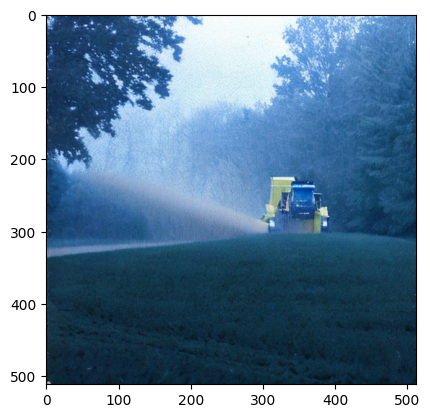

In [78]:
img_check, _  = profiled_generate_sona_outlier_optimized3(
    pipe, 
    input_image_path=test_img_path, 
    id_class_prompt=id_prompt, 
    ood_target_prompt="a photo of a harvester", 
    stop_timestep=23,
    guidance_scale=13.0,
    threshold_percentile=0.2
)
plt.imshow(img_check)

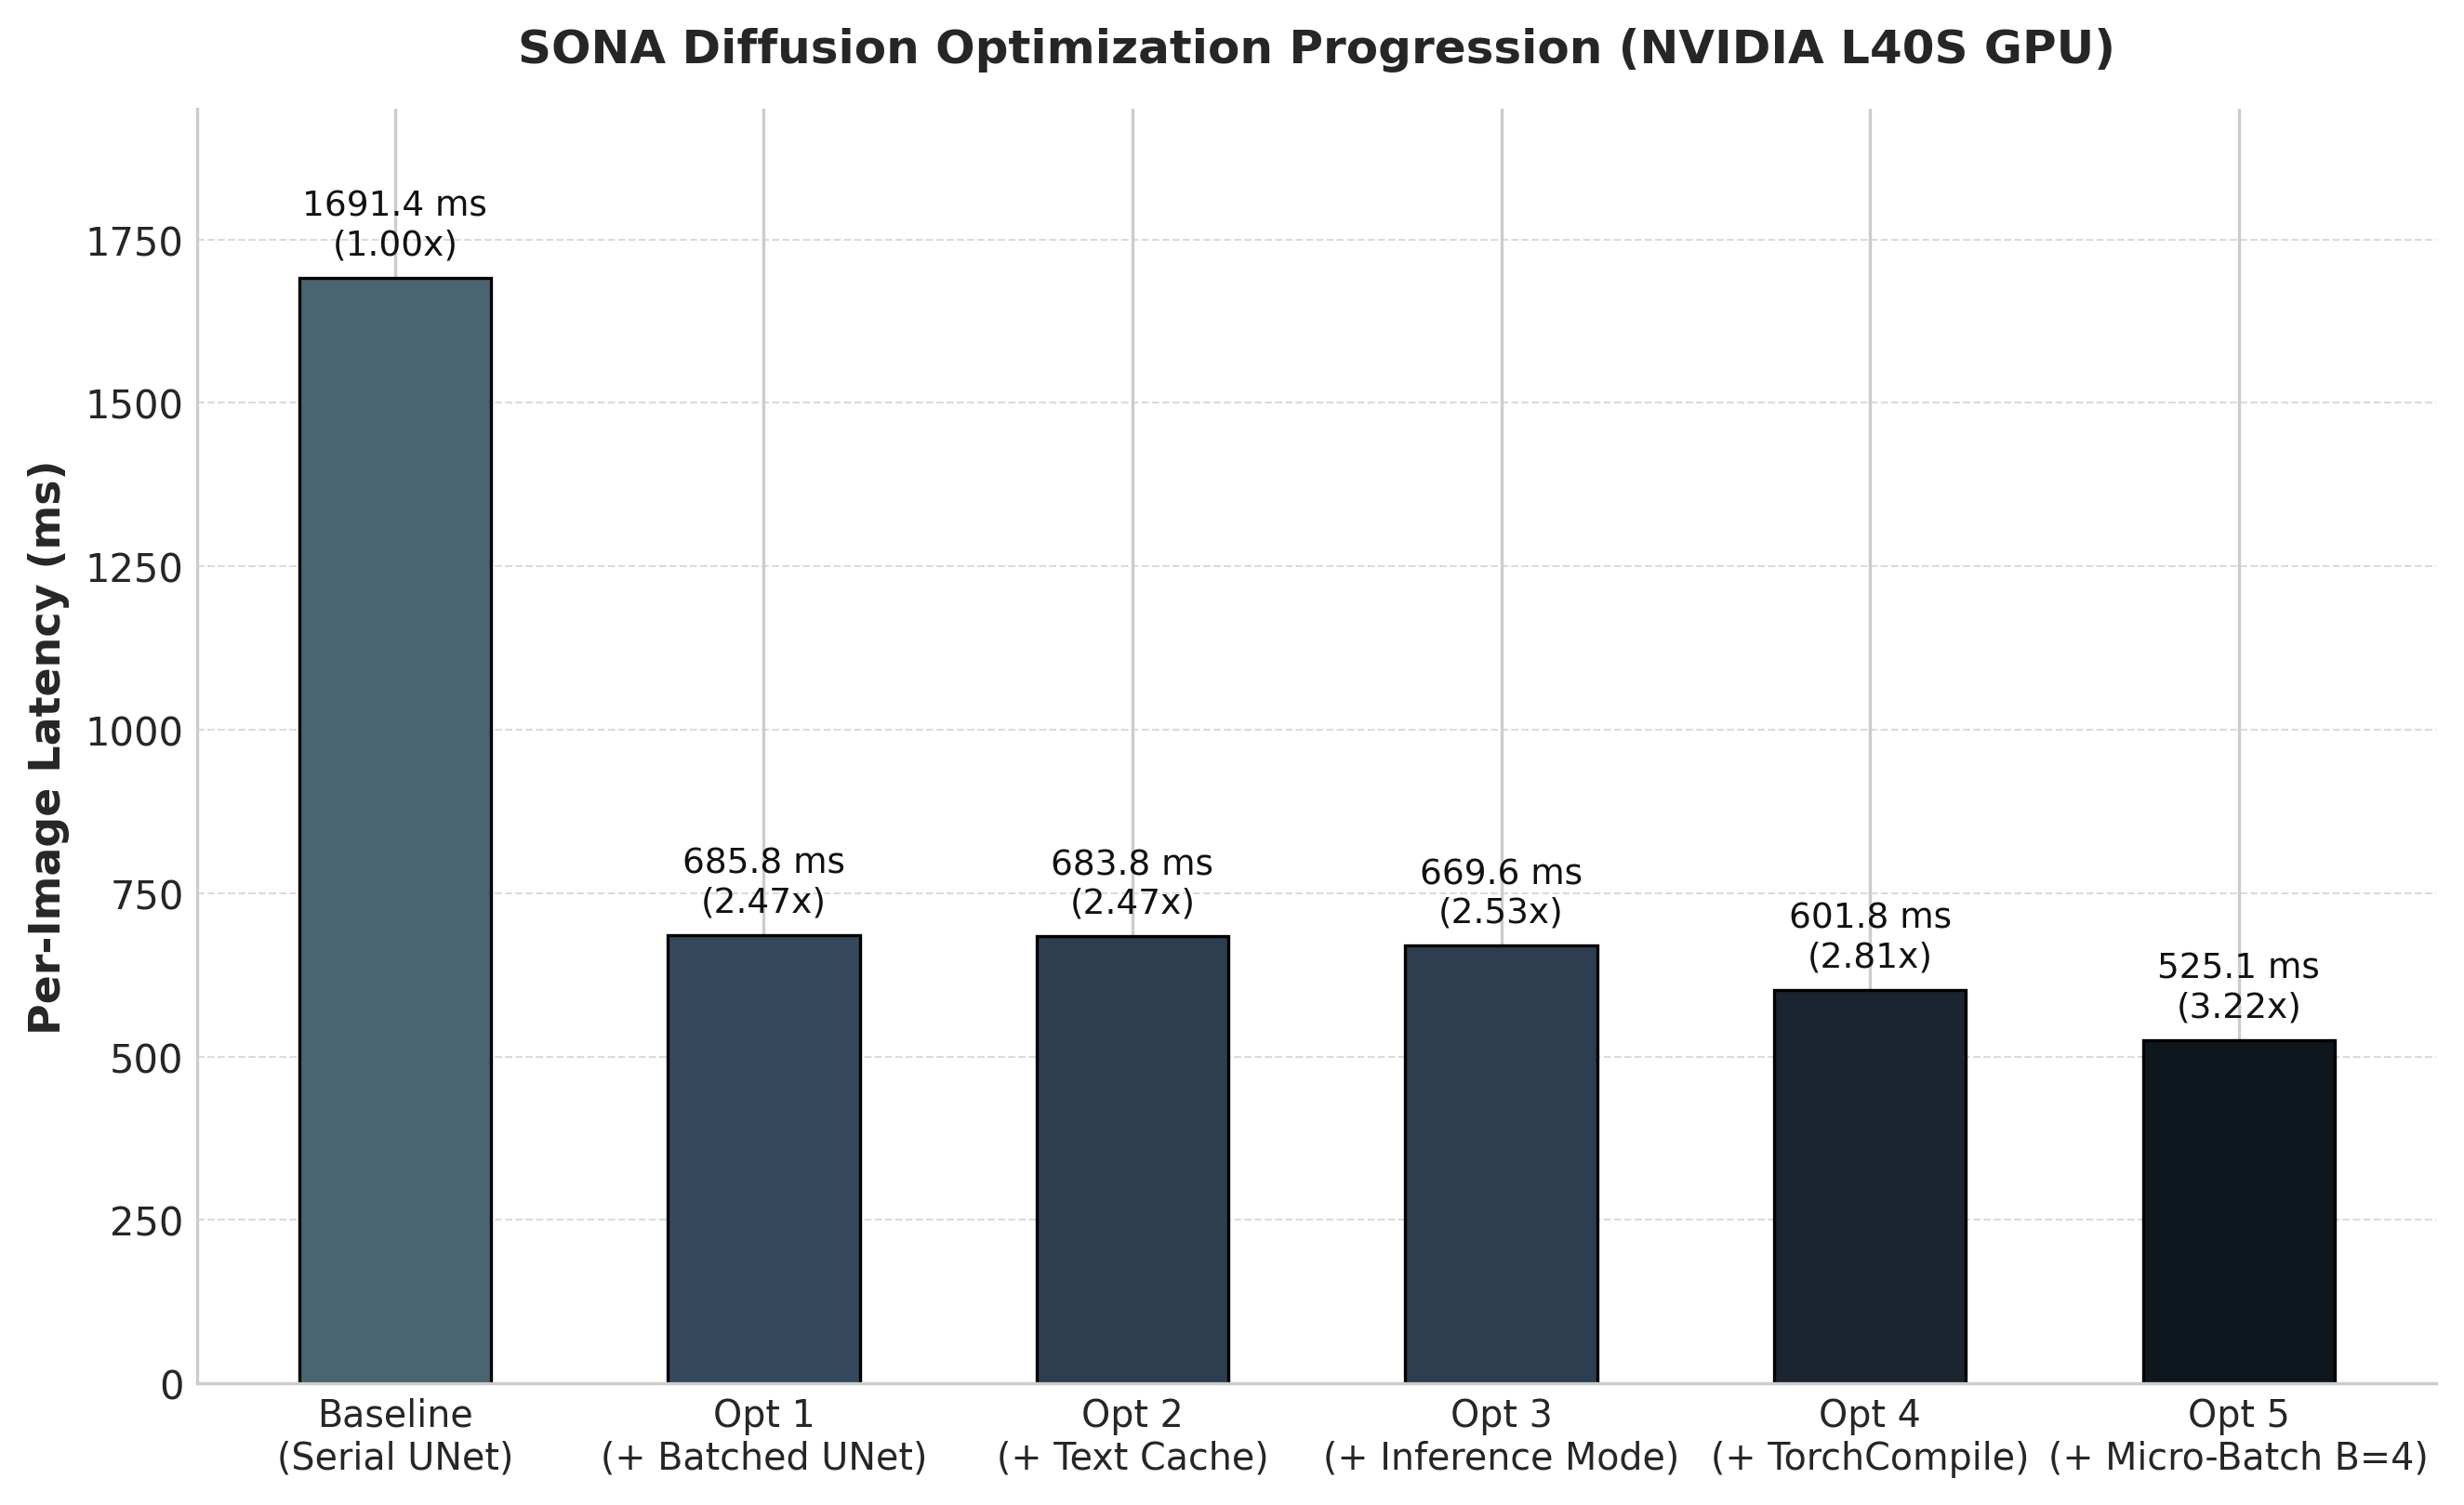

In [82]:
import matplotlib.pyplot as plt
import numpy as np

stages = [
    'Baseline\n(Serial UNet)',
    'Opt 1\n(+ Batched UNet)',
    'Opt 2\n(+ Text Cache)',
    'Opt 3\n(+ Inference Mode)',
    'Opt 4\n(+ TorchCompile)',
    'Opt 5\n(+ Micro-Batch B=4)'
]

latencies_ms = [1691.39, 685.75, 683.82, 669.58, 601.80, 525.07]
baseline_total = 1691.39
speedups = [baseline_total / l for l in latencies_ms]

# Academic style setup
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

# Muted academic color palette (Slate Blue to Deep Navy)
colors = ['#4a6572', '#34495e', '#2c3e50', '#2c3e50', '#1a252f', '#0f171e']

bars = ax.bar(stages, latencies_ms, color=colors, width=0.52, edgecolor='black', linewidth=0.8)

# Minimalist academic grid & styling
ax.set_ylabel('Per-Image Latency (ms)', fontsize=11, fontweight='bold')
ax.set_title('SONA Diffusion Optimization Progression (NVIDIA L40S GPU)', fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(0, 1950)

# Light horizontal grid lines only
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7, color='#cccccc')
ax.set_axisbelow(True)

# Remove top and right spines (IEEE/ACM style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Annotate bars cleanly with exact values and speedup factors
for bar, ms, sp in zip(bars, latencies_ms, speedups):
    yval = bar.get_height()
    label_text = f'{ms:.1f} ms\n(1.00x)' if sp == 1.0 else f'{ms:.1f} ms\n({sp:.2f}x)'
    
    ax.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 25, 
        label_text, 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='medium',
        color='#111111'
    )

plt.xticks(fontsize=9.5)
plt.tight_layout()

plt.savefig('sona_optimization_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()
